# Current Injection Step Overlay

Extract individual current steps from staircase stimulation trials, align to step onset, and plot overlaid.
- **Top subplot**: membrane potential (mV)
- **Bottom subplot**: command current (pA)
- Traces colored by step amplitude (black → light blue)

In [ ]:
import json
import os
import sys
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import h5py
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Add project root to path so we can import project modules
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Apply custom matplotlib style (lives next to this notebook)
STYLE_PATH = PROJECT_ROOT / "analysis" / "kt.mplstyle"
plt.style.use(STYLE_PATH)


def save_fig(
        fig: plt.Figure,
        fig_name: str,
        fig_fmt: str,
        fig_dir: str = r"D:\results",
        fig_size: tuple[float, float] = [6.4, 4],
        save: bool = True,
        dpi: int = 300,
        transparent_png=True,
        overwrite=False,
    ):
    """Save a figure to ``fig_dir/<fmt>/<date>-<fig_name>.<fmt>``."""
    if not save:
        return

    fig.set_size_inches(fig_size, forward=False)
    fig_fmt = fig_fmt.lower()
    fig_dir = os.path.join(fig_dir, fig_fmt)

    if not os.path.exists(fig_dir):
        os.makedirs(fig_dir)

    fig_date = datetime.today().strftime('%Y-%m-%d')
    pth = os.path.join(fig_dir, f'{fig_date}-{fig_name}.{fig_fmt}')

    if os.path.exists(pth) and not overwrite:
        return f"figure already exists: {pth}"

    if fig_fmt == 'pdf':
        metadata = {'Creator': 'kyle thieringer', 'CreationDate': None}
        fig.savefig(pth, bbox_inches='tight', metadata=metadata)
    elif fig_fmt == 'png':
        alpha = 0 if transparent_png else 1
        fig.patch.set_alpha(alpha)
        for ax in fig.get_axes():
            ax.patch.set_alpha(alpha)
        fig.savefig(pth, bbox_inches='tight', dpi=dpi)
    else:
        try:
            fig.savefig(pth, bbox_inches='tight')
        except Exception as e:
            print(f"cannot save figure: {e}")

    print(pth)


def save_fig_both(fig, fig_name, **kwargs):
    """Save a figure as both PNG and SVG to D:\\results."""
    save_fig(fig, fig_name, 'png', **kwargs)
    save_fig(fig, fig_name, 'svg', **kwargs)

In [2]:
# ── Set path to your trial HDF5 file ──
H5_PATH = Path(r"D:\data\fre023\fre023_ss31997-gfp_20260415_114059.h5")

## Load data

Works with both trial-based (`_trials.h5`) and continuous (`.h5`) recordings.

In [3]:
with h5py.File(H5_PATH, "r") as f:
    print(f.keys())
    sample_rate = int(f["metadata"].attrs["sample_rate"])
    channel_names = list(f["metadata/channel_names"][:])
    display_scales = f["metadata/display_scales"][:]
    units = list(f["metadata/units"][:])

    # Detect file type: trial-based vs continuous
    trial_keys = sorted(k for k in f.keys() if k.startswith("trial_"))

    if trial_keys:
        # Trial-based file: one array per trial, grouped by stimulus name
        file_type = "trial"
        sweeps_by_name = defaultdict(list)
        for key in trial_keys:
            grp = f[key]
            sweeps_by_name[grp.attrs["stimulus_name"]].append(
                grp["analog_input"][:]
            )
        stimulus_events = None
    else:
        # Continuous file: single long recording in /data/analog_input
        file_type = "continuous"
        sweeps_by_name = {"recording": [f["data/analog_input"][:]]}

        # Optional /stimulus_events group (present when a protocol was run)
        if "stimulus_events" in f:
            ev = f["stimulus_events"]
            stimulus_events = {
                "sample_index":   ev["sample_index"][:],
                "event_type":     [s.decode() if isinstance(s, bytes) else s
                                   for s in ev["event_type"][:]],
                "stimulus_name":  [s.decode() if isinstance(s, bytes) else s
                                   for s in ev["stimulus_name"][:]],
                "stimulus_index": ev["stimulus_index"][:],
            }
        else:
            stimulus_events = None

# Optional sidecar metadata JSON holds the full protocol definition(s)
meta_path = H5_PATH.with_name(H5_PATH.stem + "_metadata.json")
if meta_path.exists():
    metadata = json.loads(meta_path.read_text())
    protocol_runs = metadata.get("protocols", []) or []
else:
    metadata = None
    protocol_runs = []

print(f"File type: {file_type}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Channels: {channel_names}")
for name, sweeps in sweeps_by_name.items():
    print(f"  {name}: {len(sweeps)} sweep(s), shape {sweeps[0].shape}")
if stimulus_events is not None:
    n_apply = sum(1 for e in stimulus_events["event_type"] if e == "apply")
    print(f"Stimulus events: {len(stimulus_events['sample_index'])} "
          f"({n_apply} apply)")
print(f"Protocol runs in metadata: {len(protocol_runs)}")

<KeysViewHDF5 ['data', 'metadata', 'stimulus_events', 'subject']>
File type: continuous
Sample rate: 20000 Hz
Channels: [b'ScAmpOut', b'RawAmpOut', b'AmpCmd', b'Camera', b'TTLLoopback']
  recording: 1 sweep(s), shape (5, 5431400)
Stimulus events: 22 (11 apply)
Protocol runs in metadata: 0


## Build staircases

If `/stimulus_events` is present, each `apply → clear` pair defines one
staircase (one trial). Step onsets and amplitudes are detected from the
`AmpCmd` waveform *within that window*, so trials don't get split at zero
crossings and amplitudes are exact.

If no stimulus events are logged, falls back to waveform-only detection
grouped by inter-step gaps.

In [4]:
CMD_CH = 2  # AmpCmd channel index
MIN_STEP_MS = 50  # minimum plateau duration to count as a real step
MIN_TRANSITION_PA = 10  # (fallback) ignore transitions smaller than this
MIN_AMP_PA = 10  # ignore plateaus with magnitude below this
MAX_GAP_MS = 2500  # (fallback) max silence between steps in the same staircase


def ms_to_samples(ms, sr=sample_rate):
    return max(0, int(ms / 1000.0 * sr))


def _smooth_cmd_pA(sweep, sr=sample_rate, cmd_ch=CMD_CH):
    """Median-filtered AmpCmd in pA (1 ms kernel to kill transition artifacts)."""
    from scipy.ndimage import median_filter
    kernel = max(3, ms_to_samples(1.0, sr) | 1)
    return median_filter(sweep[cmd_ch] * display_scales[cmd_ch], size=kernel)


def find_pulses_above_threshold(cmd_smooth, min_amp_pA=MIN_AMP_PA,
                                min_step_ms=MIN_STEP_MS, sr=sample_rate):
    """Find every contiguous run where ``|cmd| >= min_amp_pA``.

    Each run is one current-injection pulse; gaps are near zero.  This
    recovers pulses correctly even when consecutive pulses have very
    different amplitudes that a transition-based detector would merge or
    split — the only assumption is that the protocol returns to ~0 pA
    between pulses (true for all staircase / baseline stimuli here).

    Returns list of dicts: {onset, offset, amplitude_pA} with indices
    relative to the input array.
    """
    min_samples = ms_to_samples(min_step_ms, sr)
    above = np.abs(cmd_smooth) >= min_amp_pA

    # np.diff on int8 view gives +1 at rising edges, -1 at falling edges
    ab = above.astype(np.int8)
    edges = np.diff(ab)
    rising  = np.flatnonzero(edges == 1) + 1
    falling = np.flatnonzero(edges == -1) + 1
    if above[0]:
        rising = np.concatenate(([0], rising))
    if above[-1]:
        falling = np.concatenate((falling, [len(above)]))

    pulses = []
    for onset, offset in zip(rising, falling):
        if offset - onset < min_samples:
            continue
        amp = float(np.median(cmd_smooth[onset:offset]))
        pulses.append({"onset": int(onset), "offset": int(offset),
                       "amplitude_pA": amp})
    return pulses


def _find_protocol_run(apply_sample, protocol_runs):
    """Return the most recent protocol run with start_sample <= apply_sample."""
    best = None
    for run in protocol_runs:
        start = run.get("start_sample", 0)
        if start <= apply_sample and (best is None or start > best.get("start_sample", 0)):
            best = run
    return best


def _expected_step_count(stim_def, min_amp_pA=MIN_AMP_PA):
    """Number of non-silent pulses one trial of ``stim_def`` should emit.

    For a staircase, that's the amplitudes from min_pA..max_pA (inclusive,
    step_pA) filtered by |amp| >= min_amp_pA, multiplied by staircase_repeats.
    Returns None if ``stim_def`` isn't a staircase or required fields are missing.
    """
    if stim_def.get("type") != "staircase":
        return None
    min_pA  = stim_def.get("min_pA")
    max_pA  = stim_def.get("max_pA")
    step_pA = stim_def.get("step_pA")
    repeats = stim_def.get("staircase_repeats") or 1
    if None in (min_pA, max_pA, step_pA) or step_pA <= 0:
        return None
    n = 0
    val = min_pA
    while val <= max_pA + 1e-9:
        if abs(val) >= min_amp_pA:
            n += 1
        val += step_pA
    return n * repeats


def staircases_from_events(sweep, stimulus_events, protocol_runs=None,
                           sr=sample_rate):
    """One staircase per apply→clear pair.

    Per-trial pulses are recovered via ``find_pulses_above_threshold`` on
    the trial's AmpCmd window — this yields a consistent pulse count across
    repeated trials of the same stimulus (unlike transition-based detection,
    which gets fooled by same-sign consecutive plateaus).

    When protocol metadata is available, the expected step count is printed
    alongside the found count as a sanity check.

    Returns (list of staircases, list of per-staircase meta).
    """
    if stimulus_events is None:
        return [], []

    cmd_smooth = _smooth_cmd_pA(sweep, sr=sr)
    n_total    = sweep.shape[1]

    ev_types   = stimulus_events["event_type"]
    ev_samples = stimulus_events["sample_index"]
    ev_names   = stimulus_events["stimulus_name"]
    ev_idx     = stimulus_events["stimulus_index"]
    n_ev       = len(ev_types)

    staircases = []
    meta = []

    for i, etype in enumerate(ev_types):
        if etype != "apply":
            continue
        start_sample = int(ev_samples[i])

        end_sample = n_total
        for j in range(i + 1, n_ev):
            if ev_types[j] in ("clear", "apply"):
                end_sample = int(ev_samples[j])
                break
        start_sample = max(0, min(start_sample, n_total))
        end_sample   = max(start_sample, min(end_sample, n_total))
        if end_sample <= start_sample:
            continue

        pulses = find_pulses_above_threshold(cmd_smooth[start_sample:end_sample],
                                             sr=sr)
        if not pulses:
            continue
        steps = [
            {"onset":        p["onset"]  + start_sample,
             "offset":       p["offset"] + start_sample,
             "amplitude_pA": p["amplitude_pA"]}
            for p in pulses
        ]

        expected = None
        if protocol_runs:
            run = _find_protocol_run(start_sample, protocol_runs)
            if run is not None:
                stim_list = run.get("protocol", {}).get("stimuli", [])
                sidx = int(ev_idx[i])
                if 0 <= sidx < len(stim_list):
                    expected = _expected_step_count(stim_list[sidx])

        staircases.append(steps)
        meta.append({
            "apply_sample":    start_sample,
            "clear_sample":    end_sample,
            "stimulus_name":   ev_names[i],
            "stimulus_index":  int(ev_idx[i]),
            "expected_steps":  expected,
            "found_steps":     len(steps),
        })
    return staircases, meta


# Fallback used when /stimulus_events is not present
def detect_steps(sweep, cmd_ch=CMD_CH, min_step_ms=MIN_STEP_MS,
                 min_amp_pA=MIN_AMP_PA, sr=sample_rate):
    cmd_smooth = _smooth_cmd_pA(sweep, sr=sr, cmd_ch=cmd_ch)
    return find_pulses_above_threshold(cmd_smooth, min_amp_pA=min_amp_pA,
                                       min_step_ms=min_step_ms, sr=sr)


def group_into_staircases(steps, max_gap_ms=MAX_GAP_MS, sr=sample_rate):
    """Group detected steps into staircases separated by long silences."""
    max_gap_samples = ms_to_samples(max_gap_ms, sr)
    if not steps:
        return []
    staircases = [[steps[0]]]
    for prev, s in zip(steps[:-1], steps[1:]):
        if s["onset"] - prev["offset"] > max_gap_samples:
            staircases.append([s])
        else:
            staircases[-1].append(s)
    return staircases


# --------------------------------------------------------------------------
# Build staircases
# --------------------------------------------------------------------------

all_staircases   = {}
staircase_meta   = {}
staircase_source = {}

for name, sweeps in sweeps_by_name.items():
    scs, meta = staircases_from_events(sweeps[0], stimulus_events,
                                       protocol_runs=protocol_runs)
    if scs:
        all_staircases[name]   = scs
        staircase_meta[name]   = meta
        staircase_source[name] = "stimulus_events"
    else:
        steps = detect_steps(sweeps[0])
        all_staircases[name]   = group_into_staircases(steps)
        staircase_meta[name]   = [None] * len(all_staircases[name])
        staircase_source[name] = "detected"

    print(f"\n{name}: {len(all_staircases[name])} staircase(s) "
          f"({staircase_source[name]})")
    counts = [len(sc) for sc in all_staircases[name]]
    if counts and len(set(counts)) > 1:
        print(f"  ⚠ varying step counts across trials: {counts}")
    for sc_idx, sc in enumerate(all_staircases[name]):
        amps = [s["amplitude_pA"] for s in sc]
        t_start = sc[0]["onset"] / sample_rate
        t_end = sc[-1]["offset"] / sample_rate
        m = staircase_meta[name][sc_idx]
        if m is not None:
            exp = m["expected_steps"]
            exp_str = f"/{exp}" if exp is not None else ""
            tag = (f" [{m['stimulus_name']} #{m['stimulus_index']}: "
                   f"{m['found_steps']}{exp_str} steps]")
        else:
            tag = ""
        print(f"  Staircase {sc_idx}: {len(sc)} steps, "
              f"{min(amps):+.0f} to {max(amps):+.0f} pA, "
              f"t = {t_start:.2f}–{t_end:.2f} s{tag}")


recording: 11 staircase(s) (stimulus_events)
  Staircase 0: 10 steps, -47 to +53 pA, t = 29.83–41.33 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 1: 10 steps, -47 to +53 pA, t = 74.60–86.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 2: 10 steps, -47 to +53 pA, t = 94.60–106.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 3: 10 steps, -47 to +53 pA, t = 114.60–126.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 4: 10 steps, -47 to +53 pA, t = 134.60–146.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 5: 10 steps, -47 to +53 pA, t = 154.60–166.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 6: 10 steps, -47 to +53 pA, t = 174.60–186.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 7: 10 steps, -47 to +53 pA, t = 194.60–206.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 8: 10 steps, -47 to +53 pA, t = 214.60–226.10 s [-50 to 50 pA staircase #0: 10 steps]
  Staircase 9: 10 steps, -47 to +53 pA, t = 234.60–246.10 s [-50 to 50 pA sta

## Select a staircase and extract step segments aligned to onset

In [5]:
VM_CH = 0   # ScAmpOut → membrane potential
PAD_MS = 100  # ms of baseline to show before each step onset

# ── Pick which staircase to plot ──
SWEEP_NAME = list(all_staircases.keys())[0]  # first stimulus group
STAIRCASE_IDX = 4  # which staircase within that group


def extract_steps(sweep, staircase, pad_ms=PAD_MS, sr=sample_rate):
    """Extract Vm and I_cmd segments for each step, aligned to onset.

    Returns list of dicts: {amplitude_pA, time_ms, vm_mV, i_cmd_pA}
    Time axis: t=0 at step onset, negative values = pre-step baseline.
    """
    pad_samples = ms_to_samples(pad_ms, sr)
    n_total = sweep.shape[1]
    segments = []

    for step in staircase:
        onset = step["onset"]
        offset = step["offset"]

        seg_start = max(0, onset - pad_samples)
        seg_end = min(n_total, offset + pad_samples)

        vm = sweep[VM_CH, seg_start:seg_end] * display_scales[VM_CH]
        i_cmd = sweep[CMD_CH, seg_start:seg_end] * display_scales[CMD_CH]
        t_ms = (np.arange(seg_end - seg_start) - (onset - seg_start)) / sr * 1000.0

        segments.append({
            "amplitude_pA": step["amplitude_pA"],
            "time_ms": t_ms,
            "vm_mV": vm,
            "i_cmd_pA": i_cmd,
        })

    return segments


# Extract from all sweeps of the selected stimulus
staircase_template = all_staircases[SWEEP_NAME][STAIRCASE_IDX]
all_segments = [
    extract_steps(sw, staircase_template)
    for sw in sweeps_by_name[SWEEP_NAME]
]
print(f"Extracting staircase {STAIRCASE_IDX} from '{SWEEP_NAME}': "
      f"{len(staircase_template)} steps × {len(all_segments)} sweep(s)")

Extracting staircase 4 from 'recording': 10 steps × 1 sweep(s)


## Plot overlaid step responses

In [ ]:
# Black → medium blue colormap (endpoint kept dark enough to read on white)
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "black_blue", [(0.0, 0.0, 0.0), (0.15, 0.45, 0.85)]
)


def add_scalebar(ax, x_size, x_unit, y_size, y_unit,
                 x_frac=0.95, y_frac=-0.01):
    """Draw an L-shaped scale bar *inside* the axes at the given fractional
    (x_frac, y_frac) position (1,1 = top-right).  Bar is sized in data units
    (x_size along x, y_size along y)."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]

    # Anchor the bottom-right corner of the L at the fractional position
    x1 = xlim[0] + x_frac * x_range
    y0 = ylim[0] + y_frac * y_range
    x0 = x1 - x_size
    y1 = y0 + y_size

    ax.plot([x0, x1], [y0, y0], color="black", linewidth=1.5, clip_on=False)
    ax.plot([x1, x1], [y0, y1], color="black", linewidth=1.5, clip_on=False)
    ax.text((x0 + x1) / 2, y0 - 0.02 * y_range, f"{x_size} {x_unit}",
            ha="center", va="top", fontsize=9)
    ax.text(x1 + 0.01 * x_range, (y0 + y1) / 2, f"{y_size} {y_unit}",
            ha="left", va="center", fontsize=9)


def plot_step_overlay(segment_lists, title="", figsize=(6, 5),
                      vm_scalebar=(100, "ms", 5, "mV"),
                      cmd_scalebar=(100, "ms", 50, "pA"),
                      vm_pad_mV=2.0, cmd_pad_pA=5.0,
                      trace_alpha=0.85):
    """Plot overlaid step responses colored by injection amplitude.

    Axes are tightly fitted to the data (``vm_pad_mV`` / ``cmd_pad_pA``
    padding on top & bottom) and the scale bars live inside the axes — no
    empty band below either subplot.  All traces use a constant
    ``trace_alpha`` so later-amplitude traces remain visible.
    """
    all_amps = sorted({
        seg["amplitude_pA"]
        for sweep_segs in segment_lists
        for seg in sweep_segs
    })
    norm = mcolors.Normalize(vmin=min(all_amps), vmax=max(all_amps))

    fig, (ax_vm, ax_cmd) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.2},
    )
    for sweep_segs in segment_lists:
        for seg in sweep_segs:
            color = CMAP(norm(seg["amplitude_pA"]))
            ax_vm.plot(seg["time_ms"], seg["vm_mV"], color=color,
                       linewidth=0.9, alpha=trace_alpha)
            ax_cmd.plot(seg["time_ms"], seg["i_cmd_pA"], color=color,
                        linewidth=0.9, alpha=trace_alpha)

    # Tight ylim from actual data (no matplotlib auto-padding)
    vm_vals  = np.concatenate([seg["vm_mV"]   for segs in segment_lists for seg in segs])
    cmd_vals = np.concatenate([seg["i_cmd_pA"] for segs in segment_lists for seg in segs])
    ax_vm.set_ylim(vm_vals.min() - vm_pad_mV,   vm_vals.max() + vm_pad_mV)
    ax_cmd.set_ylim(cmd_vals.min() - cmd_pad_pA, cmd_vals.max() + cmd_pad_pA)

    # Remove spines, ticks, and labels
    for ax in (ax_vm, ax_cmd):
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Estimate resting membrane potential from the pre-step baseline
    baseline_vals = []
    for sweep_segs in segment_lists:
        for seg in sweep_segs:
            mask = seg["time_ms"] < 0
            if np.any(mask):
                baseline_vals.append(np.median(seg["vm_mV"][mask]))
    rmp = np.median(baseline_vals)
    rmp_rounded = round(rmp)

    xlim = ax_vm.get_xlim()
    tick_x = xlim[0]
    ax_vm.plot(tick_x, rmp, marker="_", markersize=8, color="black", clip_on=False)
    ax_vm.text(tick_x - 0.02 * (xlim[1] - xlim[0]), rmp, f"{rmp_rounded} mV",
               ha="right", va="center", fontsize=9)

    add_scalebar(ax_vm,  *vm_scalebar)
    add_scalebar(ax_cmd, *cmd_scalebar)

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")

    fig.tight_layout()
    return fig, (ax_vm, ax_cmd)


fig, _ = plot_step_overlay(all_segments, title=None)

fig_name = f"{H5_PATH.stem}_staircase{STAIRCASE_IDX}_overlay"
save_fig_both(fig, fig_name)

plt.show()

In [14]:
data = sweeps_by_name['recording'][0]

(1400000.0, 1800000.0)

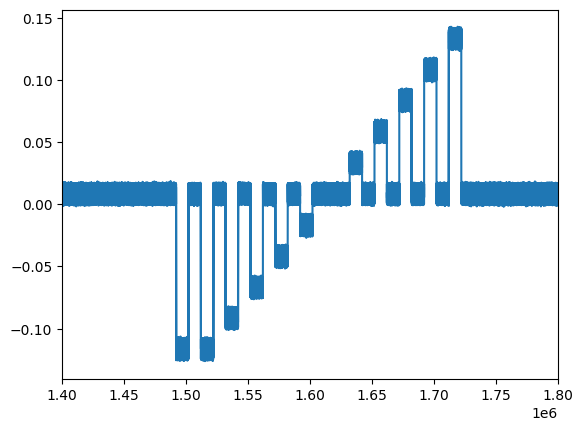

In [23]:
plt.plot(data[2])
plt.xlim(1400000,1800000)

## Save overlay figures for all staircases

C:\Users\tuthill\AppData\Local\Temp\ipykernel_5916\1932044473.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


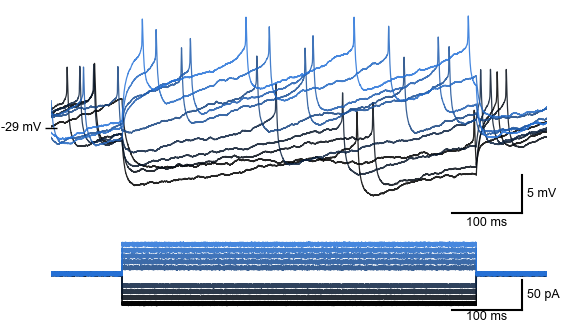

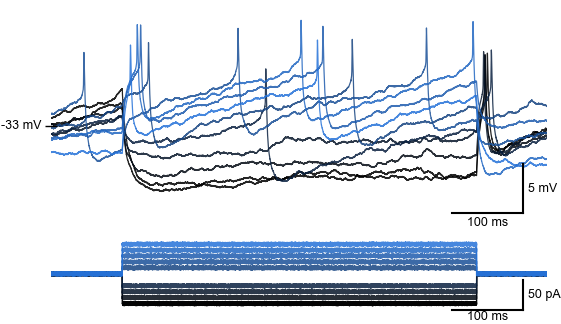

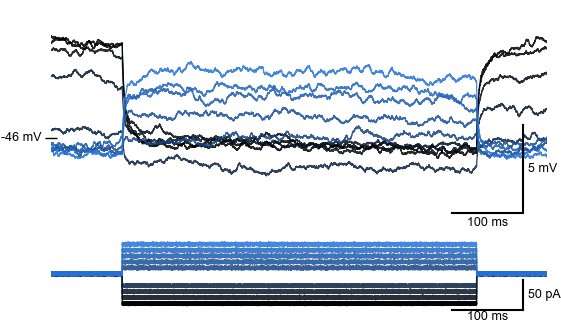

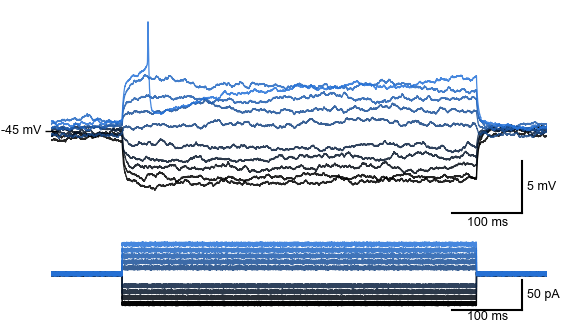

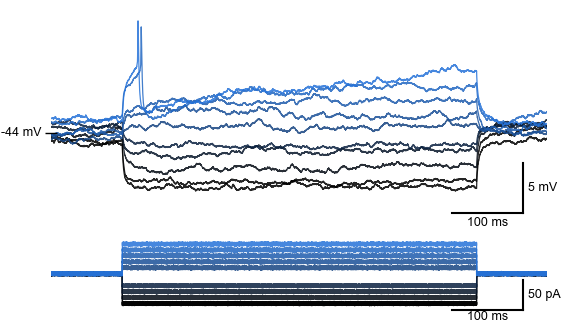

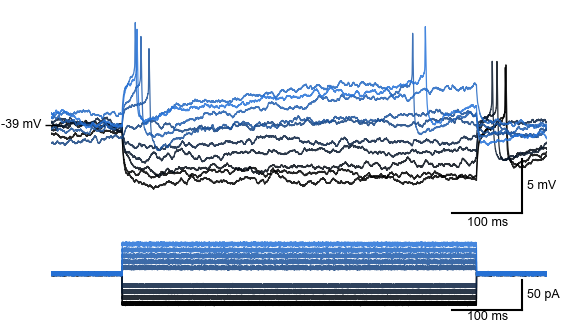

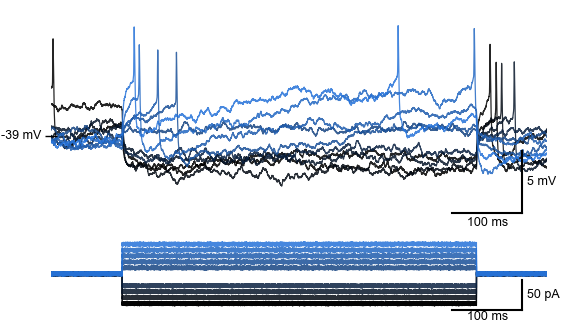

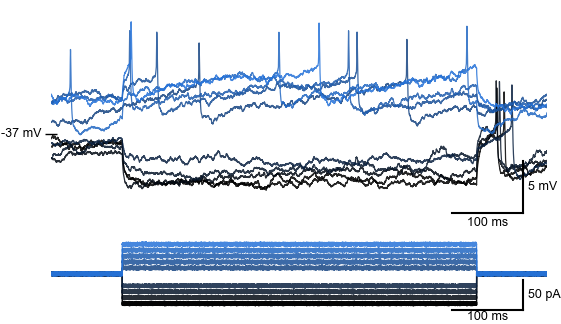

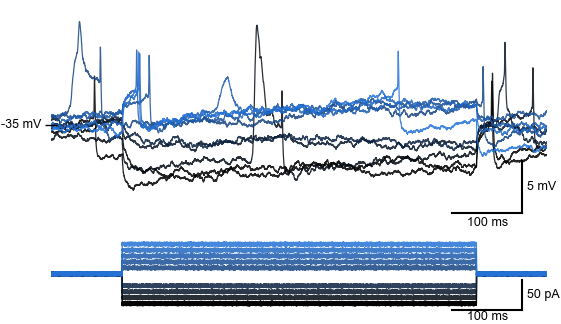

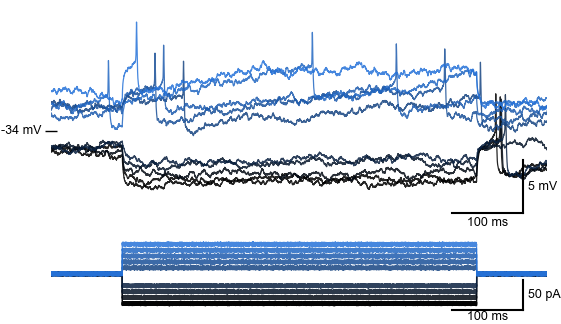

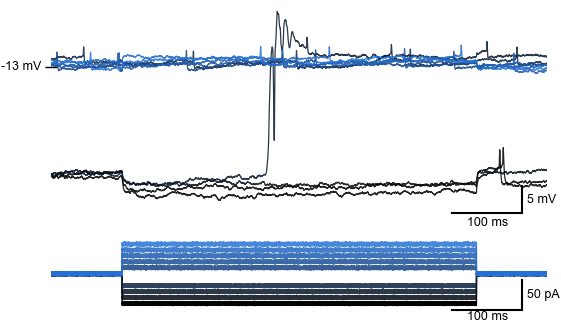

In [20]:
SHOW_EACH = True  # set True to display each figure inline as it's saved

for sweep_name, staircases in all_staircases.items():
    sweeps = sweeps_by_name[sweep_name]
    for sc_idx, staircase in enumerate(staircases):
        segments = [extract_steps(sw, staircase) for sw in sweeps]
        fig, _ = plot_step_overlay(segments, title=None)
        fig_name = f"{H5_PATH.stem}_staircase{sc_idx}_overlay"
        save_fig_both(fig, fig_name)
        if SHOW_EACH:
            plt.show()
        else:
            plt.close(fig)